-------------------------------------------------------------------------------------------------------
# EUSS Post-Retrofit Measure Packages: MP3, MP4, MP8, MP9, MP10
-------------------------------------------------------------------------------------------------------
- MP3: Min-efficiency, single-stage ASHP (15 SEER1, 9 HSPF1)
- MP4: High-efficiency, variable-speed ASHP (24-29.3 SEER1, 14 HSPF1)
- MP8: Whole Home Electrification (MP4 + High Efficiency End-uses)
- MP9: Whole-Home Electrification (MP8) + Basic Enclosure Upgrade (MP1)
- MP10: Whole-Home Electrification (MP8) + Enhanced Enclosure Upgrade (MP2)

-------------------------------------------------------------------------------------------------------
# TARE MODEL SCENARIO: 2025 Reference Case
-------------------------------------------------------------------------------------------------------
- AEO2026 fuel price projections
- AEO2026 degree-day factors
- Cambium MidCase electricity grid
- Single scenario: '2025 Reference Case'

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================
import os
from IPython import get_ipython
from datetime import datetime
import logging
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Project configuration
from config import PROJECT_ROOT

# Model constants - explicit imports for clarity
from cmu_tare_model.constants import (
    VERBOSE,
    SCC_ASSUMPTIONS,
    REMDB_COST_SCENARIO_KEYS,
    VALID_MENU_MPS,
    VALID_CATEGORIES,
    PRINT_DEBUG,
    PRINT_VERBOSE_DATAFRAMES,
    BLDG_ID_COL,
    TIMESTAMP_COL,
    ELEC_TOTAL_COL,
    BSQ_ELEC_COL,
    TEST_FIPS,
)
from cmu_tare_model.constants import (
    PRIVATE_DISCOUNT_RATE_COLS,
    PRIVATE_DISCOUNT_RATE_SHORT_KEYS,
)

# Column name builders
from cmu_tare_model.utils.column_names import (
    NPV_CASE_CATEGORIES,
    create_cost_col,
    create_capital_col,
    create_npv_col,
    create_npv_case_col,
    create_rebate_col,
    create_total_npv_col,
    create_climate_npv_col,
)
from cmu_tare_model.grid_impact.peak_load_functions import (
    find_adoption_column,
    extract_adopter_ids,
    compute_county_scenario_profile,
    plot_demand_panel,
)

# Data loading utility
from cmu_tare_model.utils.load_exported_results_to_df import load_model_run_output, load_measure_package_data

# =============================================================================
# MATPLOTLIB/SEABORN CONFIGURATION
# =============================================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.close('all')
%matplotlib inline

sns.set_theme(font='sans-serif', style='darkgrid')

# =============================================================================
# PROJECT ROOT AND TIMESTAMP SETUP
# =============================================================================
# Get the current datetime
start_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# Format the name of the exported results file using the location ID
result_export_time = datetime.now()
model_run_date_time = result_export_time.strftime("%Y-%m-%d_%H-%M")

print(f"""
PROJECT_ROOT: {PROJECT_ROOT}

Start Time: {start_time}
Model Run Timestamp: {model_run_date_time}

Active Measure Packages: {VALID_MENU_MPS}
Active Capital Cost Scenarios: {REMDB_COST_SCENARIO_KEYS}
Active SCC Assumptions: {SCC_ASSUMPTIONS}
Active Discount Rates: {PRIVATE_DISCOUNT_RATE_SHORT_KEYS}

Note: DataFrames contain columns for ALL active cost scenarios.
Visualizations default to 'v4MID' with comparative sections for other scenarios.

""")

Project root directory: c:\users\jorda\desktop\projects\cmu-tare-model

PROJECT_ROOT: c:\users\jorda\desktop\projects\cmu-tare-model

Start Time: 2026-07-07_21-49-32
Model Run Timestamp: 2026-07-07_21-49

Active Measure Packages: [0, 3, 4]
Active Capital Cost Scenarios: ['v4MID']
Active SCC Assumptions: ['lower', 'central', 'upper']
Active Discount Rates: ['fixed_base']

Note: DataFrames contain columns for ALL active cost scenarios.
Visualizations default to 'v4MID' with comparative sections for other scenarios.




In [2]:
# Select whether to begin new run or visualize existing model outputs
while True:
    try:
        start_new_model_run = str(input("""
Would you like to begin a new simulation or visualize output results from a previous model run? Please enter one of the following:
Y. I'd like to start a new model run.
N. I'd like to visualize output results from a previous model run.""")).upper()

        print(f"Enter the following input: {start_new_model_run}")

        if start_new_model_run == 'Y':
            print(f"Formatted date for use in file name: {model_run_date_time}")

            # Relative path to the file from the project root
            relative_path = os.path.join("cmu_tare_model", "model_scenarios", "tare_run_simulation_v2_3.ipynb")

            # Construct the absolute path to the file
            file_path = os.path.join(PROJECT_ROOT, relative_path)
            print(f"File path: {file_path}")

            # Storing Result Outputs in output_results folder
            output_folder_path = os.path.join(PROJECT_ROOT, "cmu_tare_model", "output_results")
            print(f"Result outputs will be exported here: {output_folder_path}")

            # On Windows, to avoid any path-escape quirks, convert backslashes to forward slashes
            file_path = file_path.replace("\\", "/")

            print(f"Running file: {file_path}")

            # iPthon magic command to run a .py file and import variables into the current IPython session
            if os.path.exists(file_path):
                get_ipython().run_line_magic('run', f'-i {file_path}')  # If your path has NO spaces, no quotes needed.
            else:
                print(f"File not found: {file_path}")

            break  # Exit the loop if input is 'Y'
            
        elif start_new_model_run == 'N':
            # Enter the date time of the model run in the following format: YYYY-MM-DD_HH-MM
            model_run_date_time = str(input("Enter the date time of the model run in the following format YYYY-MM-DD_HH-MM: "))
            location_id = str(input("Enter the location ID used in the model run (e.g., 'National' or 'PA'): "))
            
            # Load model run results
            print(f"Loading model run results for location ID: {location_id} and timestamp: {model_run_date_time}")

            # Storing Result Outputs in output_results folder
            output_folder_path = os.path.join(PROJECT_ROOT, "cmu_tare_model", "output_results")
            print(f"Past model run results will be loaded from here: {output_folder_path}")
            
            break  # Exit the loop if input is 'N'
        
        else:
            print("Invalid input. Please enter 'Y' or 'N'.")
    
    except Exception as e:
        print("An error occurred:", e)
        print("Please try again.")

Enter the following input: Y
Formatted date for use in file name: 2026-07-07_21-49
File path: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\model_scenarios\tare_run_simulation_v2_3.ipynb
Result outputs will be exported here: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\output_results
Running file: c:/users/jorda/desktop/projects/cmu-tare-model/cmu_tare_model/model_scenarios/tare_run_simulation_v2_3.ipynb

Running the model for the following measure packages:

VALID_MENU_MPS = [0, 3, 4]

The results will be exported using the export_model_run_output function.
Documentation for this function:
Export model run results to CSV files with sensitivity tracking.

    This function exports DataFrame results to CSV files organized by result type.
    For retrofit summary results, it uses short discount rate keys for directory naming
    while maintaining backward compatibility with full column names in exported DataFrames.

    Directory Structure:
        baseli

In [3]:
if VERBOSE:
    print(f"""
    ====================================================================================================================================================================
    LOAD SCENARIO DATA
    ====================================================================================================================================================================
    The load_model_run_output function loads scenario data from a specified folder and date. Additional details are provided below:
        
    Documentation for the load_model_run_output function:
    {load_model_run_output.__doc__}

    -----------------------------------------------------------------------------------------------
    LOADING SCENARIO DATA ...

    These parameters are common to all function calls:
    Output folder path: {output_folder_path}
    Model run date time: {model_run_date_time}
    """)


    LOAD SCENARIO DATA
    The load_model_run_output function loads scenario data from a specified folder and date. Additional details are provided below:

    Documentation for the load_model_run_output function:
    Load model run results from CSV files (reverse of export_model_run_output).

    This function loads DataFrame results from CSV files organized by result type.
    It mirrors the export_model_run_output() function exactly, using the same
    parameters to construct the correct file path.

    Args:
        results_category: Category of results being loaded. Valid options:
            - 'summary_baseline': Baseline summary results
            - 'summary': Retrofit summary results (requires discount_rate)
            - 'damages_climate_IRA', 'damages_climate_noIRA': Climate damages
            - 'fuel_costs_IRA', 'fuel_costs_noIRA': Fuel costs
        menu_mp: Measure package identifier (0 for baseline, VALID_MENU_MPS for retrofits).
        output_folder_path: Base direct

-------------------------------------------------------------------------------------------------------
# LOAD MODEL RUN OUTPUT FOR ANALYSIS + VISUALS
-------------------------------------------------------------------------------------------------------

In [4]:
# =======================================================================================================
# Baseline Scenario: Measure Package 0 (MP0)
# =======================================================================================================
menu_mp = 0

df_outputs_baseline_home = load_model_run_output(
    results_category='summary_baseline',
    menu_mp=menu_mp,
    output_folder_path=output_folder_path,
    location_id=location_id,
    results_export_formatted_date=model_run_date_time,
    use_chunked_loading=True,
    chunk_size=10000
)

In [5]:
# =============================================================================
# LOAD MODEL RESULTS: Based on VALID_MENU_MPS
# =============================================================================
# Only load measure packages that are in VALID_MENU_MPS.
# MP0 (baseline) is loaded separately above.
NON_BASELINE_MPS = [mp for mp in VALID_MENU_MPS if mp != 0]

# Convenience mapping for downstream code
DATAFRAMES_BY_MP = {}

for mp in NON_BASELINE_MPS:
    DATAFRAMES_BY_MP[mp] = load_measure_package_data(
        mp, output_folder_path, location_id, model_run_date_time
    )

print(f"\nLoaded measure packages: {list(DATAFRAMES_BY_MP.keys())}")

Loading MP3 data...
  fixed_base: [OK]
MP3 loading complete!

Loading MP4 data...
  fixed_base: [OK]
MP4 loading complete!


Loaded measure packages: [3, 4]


-------------------------------------------------------------------------------------------------------
# ECONOMIC ADOPTION POTENTIAL
-------------------------------------------------------------------------------------------------------

In [6]:
# =============================================================================
# UPDATE IMPORTS FOR NEW ADOPTION DOT PLOT VISUALIZATION FUNCTIONS
# =============================================================================

from cmu_tare_model.adoption_potential.data_processing.visuals_adoption_potential import (
    build_adoption_scenario_names,
    create_multiIndex_adoption_df,
    print_adoption_decision_percentages,
    subplot_grid_adoption_vBar
)

if VERBOSE:

    print(f"""  
    ====================================================================================================================================================================
    ADOPTION POTENTIAL VISUALIZATION
    ====================================================================================================================================================================

    --------------------------------------------------------
    CREATE MULTI-INDEX DF FOR ADOPTION POTENTIAL
    --------------------------------------------------------
    visuals_adoption_potential.py file contains the documentation for the create_multiIndex_adoption_df function.

    --------------------------------------------------------
    VISUALIZE ADOPTION POTENTIAL SUBPLOT GRID
    --------------------------------------------------------
    visuals_adoption_potential.py file contains the documentation for the subplot_grid_adoption_vBar function.
        
    --------------------------------------------------------------------------------------------------------------------------------------------------------------------

    """)

  
    ADOPTION POTENTIAL VISUALIZATION

    --------------------------------------------------------
    CREATE MULTI-INDEX DF FOR ADOPTION POTENTIAL
    --------------------------------------------------------
    visuals_adoption_potential.py file contains the documentation for the create_multiIndex_adoption_df function.

    --------------------------------------------------------
    VISUALIZE ADOPTION POTENTIAL SUBPLOT GRID
    --------------------------------------------------------
    visuals_adoption_potential.py file contains the documentation for the subplot_grid_adoption_vBar function.

    --------------------------------------------------------------------------------------------------------------------------------------------------------------------

    


## Does the heat pump pay for itself?

An **economic adopter** is a home where the heat pump's extra upfront cost is
recovered from energy-bill savings alone -- no climate or health benefit is
needed to justify the investment.

**The rule:** a home is an economic adopter if its incremental private
NPV >= 0. Break-even counts as adoption.

| Value | Meaning |
|-------|---------|
| `True`  | Heat pump covers its incremental cost (or better) from bill savings |
| `False` | Valid home that cannot recover the incremental cost from savings alone |
| `NaN`   | Excluded: invalid baseline fuel/tech or not in this measure package |

Climate and health damages are computed elsewhere and reported as outcomes,
not as inputs to this decision.

In [ ]:
# =============================================================================
# ECONOMIC ADOPTION -- setup: imports, parameters, and shared inputs
# =============================================================================
# Transported from calculate_postTARE_am_kpis_demand_bill_savings. Column names
# use the six-case NPV_CASE_CATEGORIES scheme; there is no WTP or cost-scenario
# token in adopter column names.
import geopandas as gpd
import matplotlib.lines as mlines
from matplotlib.colors import Normalize

from cmu_tare_model.adoption_potential.determine_economic_adoption_potential import (
    economic_adoption_decision,
)
from cmu_tare_model.utils.modeling_params import define_scenario_params
from cmu_tare_model.utils.column_names import create_adoption_col
from cmu_tare_model.adoption_kpis import load_euss_baseline, compute_adoption_rate
from cmu_tare_model.adoption_kpis.visualize_geospatial_data import (
    plot_combined_choropleth,
)
from cmu_tare_model.adoption_kpis.data_loading import COUNTY_SHAPEFILE_PATH
from cmu_tare_model.adoption_potential.data_processing.visuals_adoption_dotplot import (
    plot_adoption_panel,
    build_econ_plot_df,
)

# Base-case parameters. The economic-adopter column name encodes these:
# e.g. 'ref2025_mp3_heatingLCC_coolingLCC_sub_econ_adopter_fixed_base'.
_POLICY = '2025 Reference Case'
_DISCOUNT_COL = 'private_discount_rate_fixed_base'
_COST = 'v4MID'                 # REMDB v4 midpoint (retained for API compat)
discount_rate = 'fixed_base'    # 7% fixed discount rate
SAVE_FIGURES = False            # Set True to write figure files to disk
GRID_IMPACT_ANALYSIS = True     # Set True to run BSQ-based grid impact analysis

# The adoption analysis runs on every loaded non-baseline measure package.
selected_mps = NON_BASELINE_MPS
HEATING_MEASURE_PACKAGES = selected_mps

# Equipment subtitles used as panel/map titles. Covers this notebook's MP set.
HEATING_MP_SUBTITLES = {
    3: 'Single-stage, min-efficiency ASHP (15 SEER1, 9 HSPF1)',
    4: 'Variable-speed, high-efficiency ASHP (24-29.3 SEER1, 13-14 HSPF1)',
    8: 'Whole-Home Electrification (High Efficiency)',
    9: 'Whole-Home Electrification + Basic Enclosure Upgrade',
    10: 'Whole-Home Electrification + Enhanced Enclosure Upgrade',
}

# EUSS baseline provides household weights for county adoption-rate weighting.
df_baseline = load_euss_baseline()
print(f"Baseline: {len(df_baseline):,} occupied SF homes")

# County shapefile for the adoption-rate choropleth. Missing shapefile is a
# warning, not an error -- the choropleth cell is skipped if it is unavailable.
gdf_counties_raw = None
try:
    gdf_counties_raw = gpd.read_file(COUNTY_SHAPEFILE_PATH)
    print(f"[OK] County shapefile loaded: {len(gdf_counties_raw)} features")
except Exception as e:
    print(f"[WARN] County shapefile not loaded: {e}")

Loading baseline from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\euss_data\resstock_amy2018_release_1.1\national\csv\baseline_metadata_and_annual_results.csv


c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\adoption_kpis\data_loading.py:188: DtypeWarning: Columns (61,113,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, index_col="bldg_id")


  After occupancy filter: 482,597 / 548,916
  After housing type filter (['Single-Family Attached', 'Single-Family Detached']): 331,531
Baseline: 331,531 occupied SF homes
[OK] County shapefile loaded: 3235 features


In [8]:
# Generate the SIX economic-adopter columns (one per NPV case) for each measure
# package. After this cell, every case column exists in the 'fixed_base' frame:
#   ref2025_mp{mp}_heatingSavings_coolingLCC_{sub,unsub}_econ_adopter_fixed_base
#   ref2025_mp{mp}_heatingLCC_coolingSavings_{sub,unsub}_econ_adopter_fixed_base
#   ref2025_mp{mp}_heatingLCC_coolingLCC_{sub,unsub}_econ_adopter_fixed_base
for mp in selected_mps:
    df_tare = DATAFRAMES_BY_MP[mp]['fixed_base']
    scenario_prefix = define_scenario_params(mp, _POLICY)[0]
    expected_adopter_cols = [
        create_adoption_col(scenario_prefix, npv_case, '_fixed_base')
        # Replace with the constant NPV_CASE_CATEGORIES to avoid hardcoding the list.
        for npv_case in NPV_CASE_CATEGORIES
    ]
    missing_cols = [c for c in expected_adopter_cols if c not in df_tare.columns]
    if missing_cols:
        df_econ = economic_adoption_decision(
            df_tare,
            menu_mp=mp,
            policy_scenario=_POLICY,
            discount_rate_col_name=_DISCOUNT_COL,
            cost_scenario=_COST,
            verbose=False,
        )
        # Copy only newly created columns back into the canonical frame.
        new_cols = [c for c in df_econ.columns if c not in df_tare.columns]
        for col in new_cols:
            DATAFRAMES_BY_MP[mp]['fixed_base'][col] = df_econ[col]
        print(f"[OK] MP{mp}: {len(new_cols)} econ-adopter columns added")
    else:
        print(f"[SKIP] MP{mp}: all economic-adopter columns already present")

print("\n[OK] Economic-adopter columns present for all selected MPs")

[SKIP] MP3: all economic-adopter columns already present
[SKIP] MP4: all economic-adopter columns already present

[OK] Economic-adopter columns present for all selected MPs


In [9]:
# County-level economic adoption rate. Uses heatingLCC_coolingLCC_sub (both
# avoided replacements credited, subsidized) as the headline adoption metric.
print(f"\n{'='*60}")
print("Economic Adoption Rate -- 2025 Reference Case")
print(f"{'='*60}")

econ_adoption_rate_results = {}
for mp in selected_mps:
    print(f"\n===== {HEATING_MP_SUBTITLES.get(mp, f'MP{mp}')} =====")
    df_tare = DATAFRAMES_BY_MP[mp]['fixed_base']
    prefix = define_scenario_params(mp, _POLICY)[0]
    adoption_col = create_adoption_col(
        scenario_prefix=prefix,
        npv_case='heatingLCC_coolingLCC_sub',
        method_suffix='_fixed_base',
    )
    print(f'  Adoption column: {adoption_col}')
    # adopter_tiers=[True] counts 1.0 (adopter) vs 0.0; NaN (excluded) rows are
    # ignored automatically by compute_adoption_rate.
    df_adopt = compute_adoption_rate(
        df_tare,
        adoption_col=adoption_col,
        adopter_tiers=[True],
        geo_level='county',
        df_euss=df_baseline,
        verbose=True,
    )
    econ_adoption_rate_results[mp] = df_adopt

print("\n[OK] Economic adoption rate complete (county-level)")


Economic Adoption Rate -- 2025 Reference Case

===== Single-stage, min-efficiency ASHP (15 SEER1, 9 HSPF1) =====
  Adoption column: ref2025_mp3_heatingLCC_coolingLCC_sub_econ_adopter_fixed_base
Counties with data: 67 / 67
Mean counties adoption rate: 36.8%

===== Variable-speed, high-efficiency ASHP (24-29.3 SEER1, 13-14 HSPF1) =====
  Adoption column: ref2025_mp4_heatingLCC_coolingLCC_sub_econ_adopter_fixed_base
Counties with data: 67 / 67
Mean counties adoption rate: 44.5%

[OK] Economic adoption rate complete (county-level)


In [10]:
if gdf_counties_raw is not None:
    _adopt_cmap = 'Greens'
    _adopt_norm = Normalize(vmin=0, vmax=100)

    print("\n--- Summary: adoption_rate_pct ---")
    for mp in selected_mps:
        _v = econ_adoption_rate_results[mp]['adoption_rate_pct'].dropna()
        _pct_high = (_v >= 50).mean() * 100
        print(f"  MP{mp}: n={len(_v):,} counties | "
              f"min={_v.min():.1f}% | med={_v.median():.1f}% | "
              f"mean={_v.mean():.1f}% | max={_v.max():.1f}% | "
              f"{_pct_high:.1f}% of counties >= 50% adoption potential")

    plot_combined_choropleth(
        gdf_counties_raw, econ_adoption_rate_results,
        column='adoption_rate_pct',
        title_template=HEATING_MP_SUBTITLES,
        cbar_label='Share of households recovering incremental costs\n'
                   'through discounted operational savings (%)',
        cmap=_adopt_cmap, norm=_adopt_norm,
        selected_mps=selected_mps,
        geo_level='county',
        save_figure=SAVE_FIGURES,
        output_path=os.path.join(PROJECT_ROOT, 'county_econ_adoption_rate_combined.png'),
    )
    print("[OK] Economic adoption choropleth generated")
else:
    print("[WARN] Adoption choropleth skipped -- county shapefile not available")


--- Summary: adoption_rate_pct ---
  MP3: n=67 counties | min=8.0% | med=35.6% | mean=36.8% | max=57.9% | 11.9% of counties >= 50% adoption potential
  MP4: n=67 counties | min=23.8% | med=44.6% | mean=44.5% | max=69.2% | 28.4% of counties >= 50% adoption potential


[OK] Economic adoption choropleth generated


## Economic Adoption Potential Dotplot

Two markers per row: 
- circle = heating replacement credit only
(`heatingLCC_coolingSavings_sub`)
- square = heating + cooling replacement
credit (`heatingLCC_coolingLCC_sub`). 

The annotation shows the subsidized minus unsubsidized adoption-rate delta for the same case.

--- MP3 economic adoption summary ---
  Heating Repl. Credit: 25.8%
  Heating + Cooling Repl. Credit: 38.5%

--- MP4 economic adoption summary ---
  Heating Repl. Credit: 32.5% (+11.8% vs unsubsidized)
  Heating + Cooling Repl. Credit: 52.6% (+23.6% vs unsubsidized)



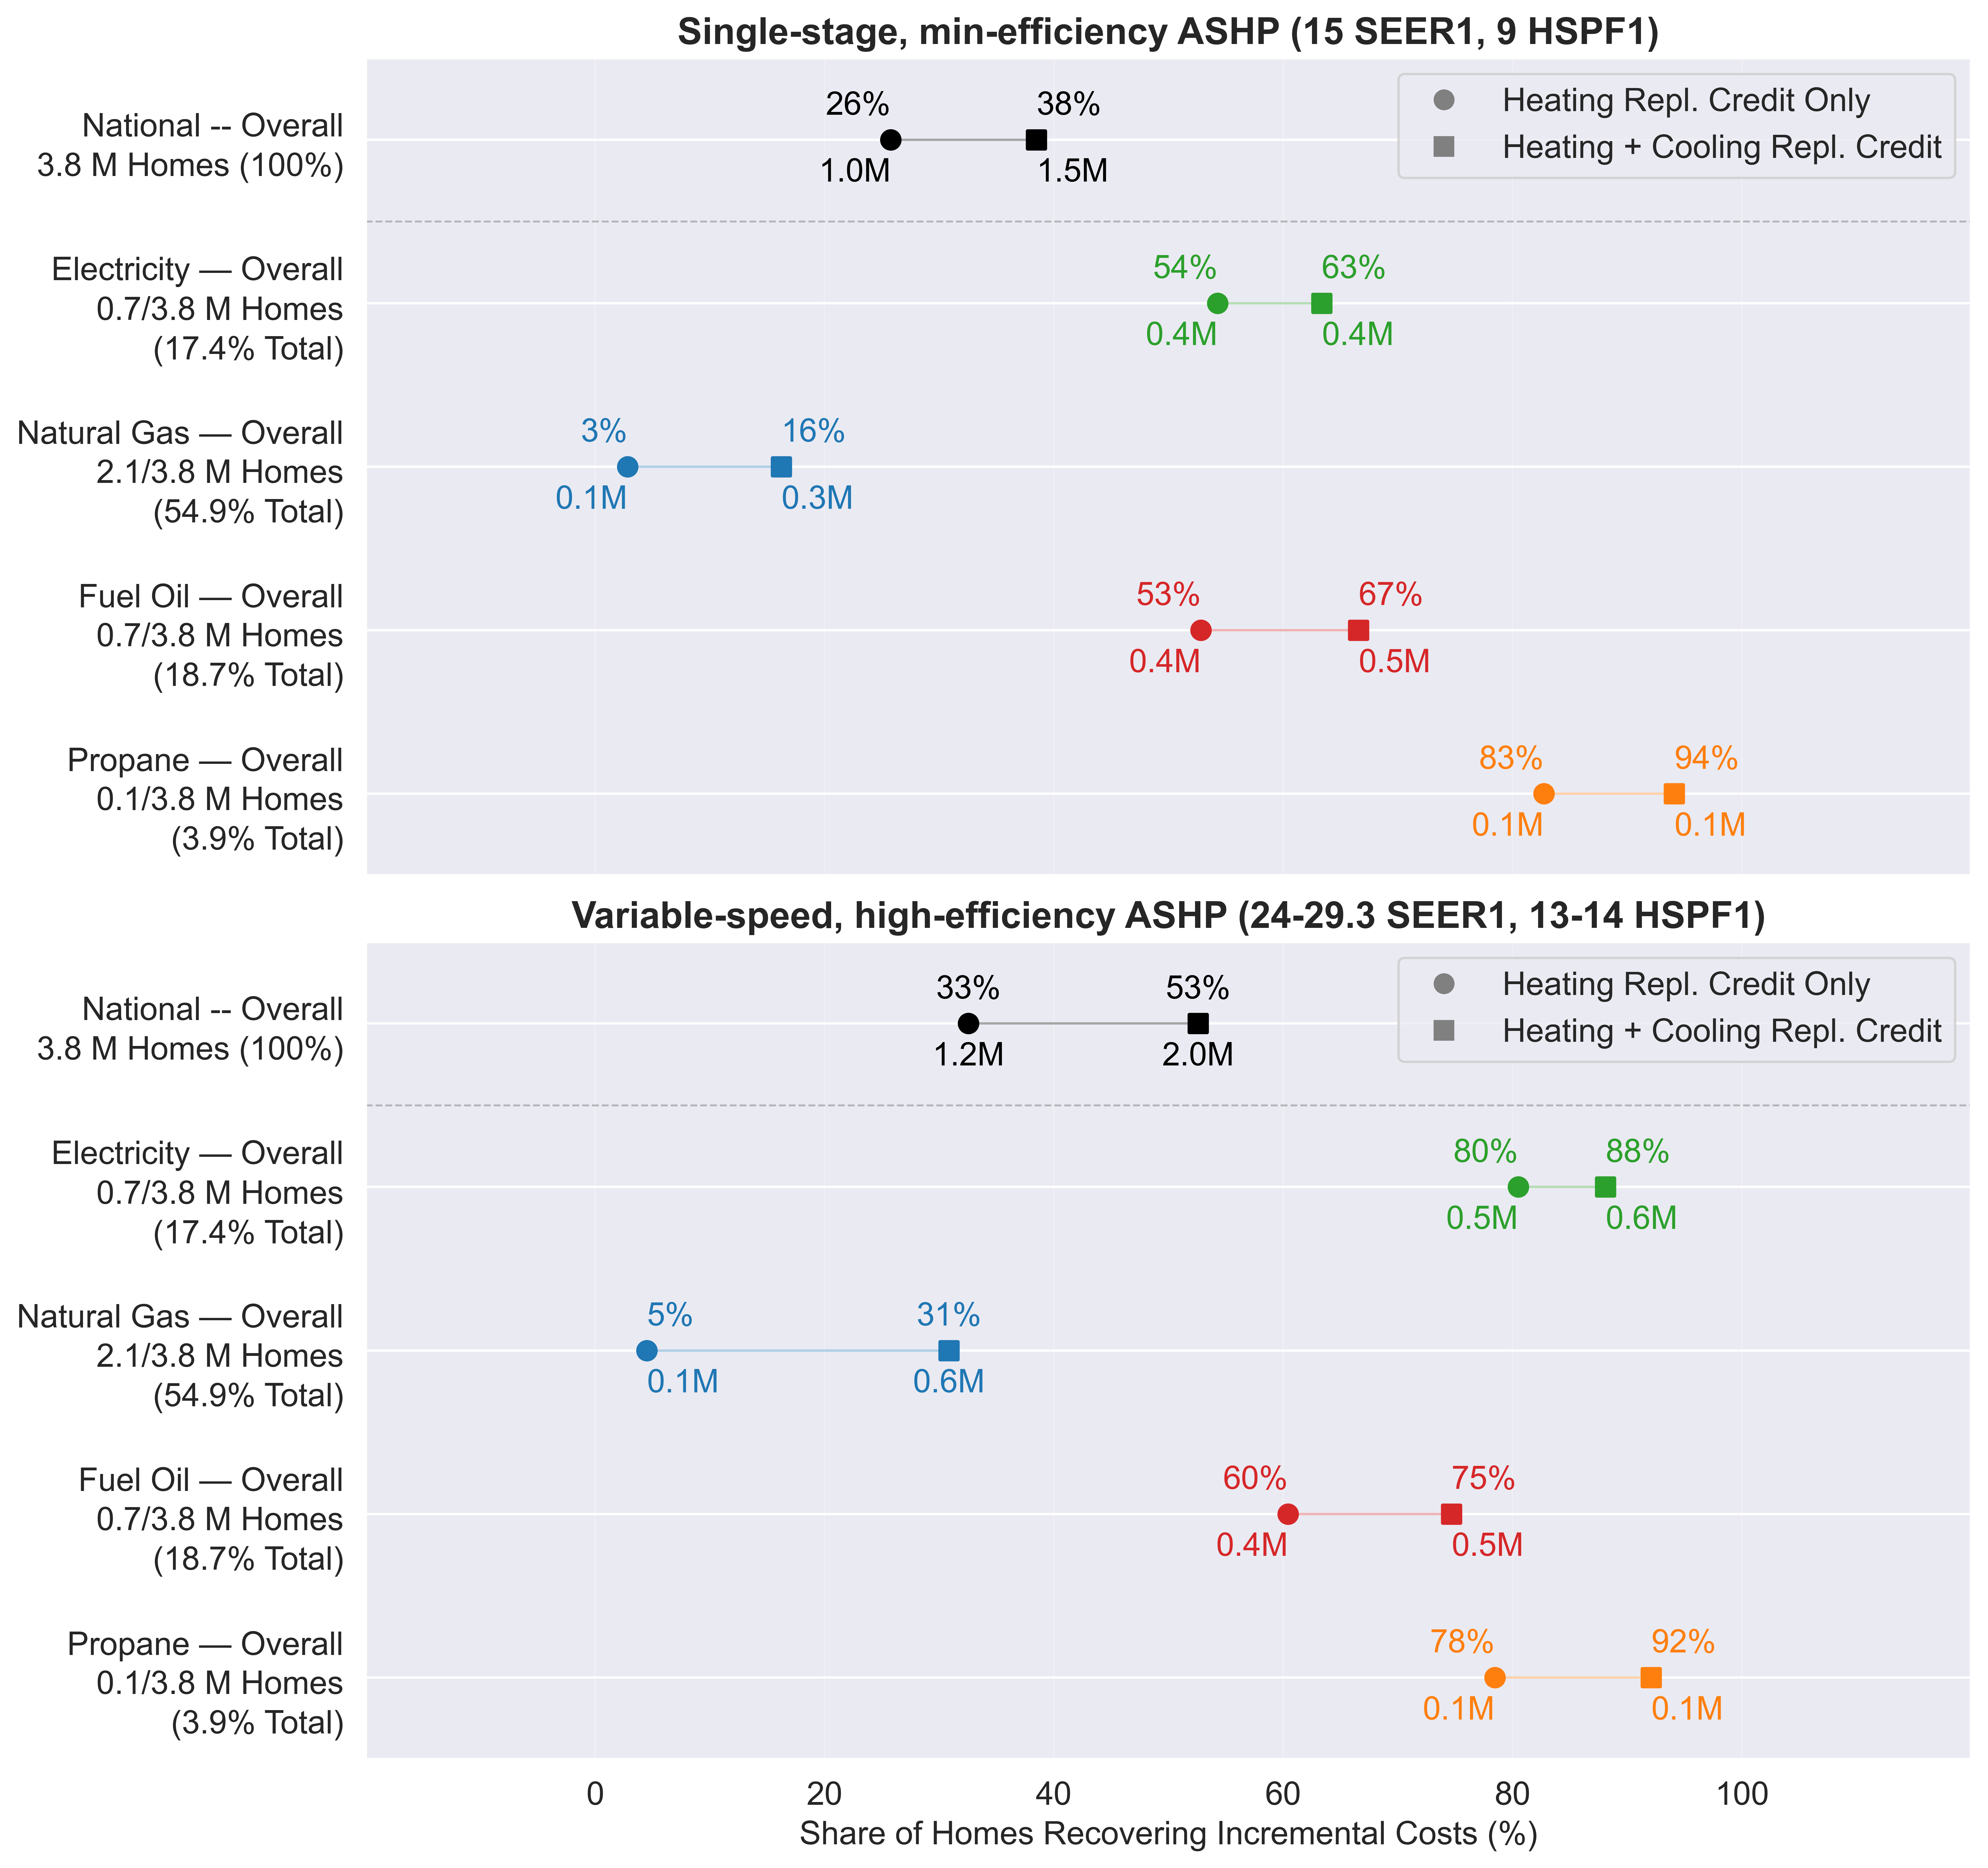

In [11]:
_ECON_CASE_MARKERS = {
    'Heating Repl. Credit':           'o',   # circle -- heatingLCC_coolingSavings
    'Heating + Cooling Repl. Credit': 's',   # square -- heatingLCC_coolingLCC
}
_ECON_CASES = ['Heating Repl. Credit', 'Heating + Cooling Repl. Credit']
_ECON_GROUPING_ORDER = [
    'National -- Overall',
    'Electricity -- Overall',
    'Natural Gas -- Overall',
    'Fuel Oil -- Overall',
    'Propane -- Overall',
]

if not HEATING_MEASURE_PACKAGES:
    print("No active heating measure packages -- skipping economic adoption dotplot.")
else:
    # National fuel counts, weighted to homes (same method as the tier dotplot).
    _src = DATAFRAMES_BY_MP[HEATING_MEASURE_PACKAGES[0]][discount_rate]
    fuel_counts_millions = {
        str(fuel): int(n) * 242 / 1_000_000
        for fuel, n in _src.groupby('base_heating_fuel', observed=True).size().items()
    }

    n_mps = len(HEATING_MEASURE_PACKAGES)
    fig, axes = plt.subplots(
        n_mps, 1, figsize=(12, 6 * n_mps), sharex=True, sharey=True,
    )
    if n_mps == 1:
        axes = [axes]

    for row_idx, mp in enumerate(HEATING_MEASURE_PACKAGES):
        ax = axes[row_idx]
        panel_title = f'{HEATING_MP_SUBTITLES.get(mp, f"MP{mp}")}'
        source_df = DATAFRAMES_BY_MP[mp][discount_rate]

        plot_df = build_econ_plot_df(
            source_df, mp, cost_scenario=_COST, discount_rate=discount_rate,
        )

        # Per-panel national summary (headline adoption rate per case).
        print(f"--- MP{mp} economic adoption summary ---")
        for case_label in _ECON_CASES:
            nat_row = plot_df[
                (plot_df['grouping'] == 'National -- Overall') &
                (plot_df['tier_label'] == case_label)
            ]
            if not nat_row.empty:
                rate = nat_row.iloc[0]['case_b_pct']
                delta = nat_row.iloc[0]['delta_pct']
                if delta == 0:
                    print(f"  {case_label}: {rate:.1f}%")
                else:
                    sign = '+' if delta >= 0 else ''
                    print(f"  {case_label}: {rate:.1f}% ({sign}{delta:.1f}% vs unsubsidized)")
        print()

        plot_adoption_panel(
            plot_df, ax,
            grouping_order=_ECON_GROUPING_ORDER,
            title=panel_title,
            title_fontsize=16,
            ytick_fontsize=14,
            annotation_fontsize=14,
            annotation_x_offset_pts=0,
            annotation_y_offset_pts=8,
            xlim_margin=20,
            fuel_counts_millions=fuel_counts_millions,
            custom_tier_markers=_ECON_CASE_MARKERS,
        )
        ax.tick_params(axis='both', labelsize=14)

        legend_handles = [
            mlines.Line2D([], [], marker='o', color='none',
                          markerfacecolor='gray', markeredgecolor='gray',
                          markersize=8, linestyle='None',
                          label='Heating Repl. Credit Only'),
            mlines.Line2D([], [], marker='s', color='none',
                          markerfacecolor='gray', markeredgecolor='gray',
                          markersize=8, linestyle='None',
                          label='Heating + Cooling Repl. Credit'),
        ]
        ax.legend(handles=legend_handles, loc='upper right', fontsize=14, frameon=True)

        if row_idx < n_mps - 1:
            ax.set_xlabel('')

    fig.tight_layout(rect=[0.0, 0.02, 1.0, 0.96])

    if SAVE_FIGURES:
        out_dir = os.path.join(PROJECT_ROOT, 'figures')
        os.makedirs(out_dir, exist_ok=True)
        for ext in ('png', 'pdf'):
            fig.savefig(
                os.path.join(out_dir, f'figure6_econ_adoption_dotplot_{location_id}.{ext}'),
                dpi=600, bbox_inches='tight',
            )
        print(f"Saved econ adoption dotplot to {out_dir}")
    plt.show()

# GRID IMPACT ANALYSIS

In [12]:
# # PLACEHOLDER: Run the cleaned up calculate_postTARE_ts_aws_peak_demand.ipynb file here
# # UPDATES NEEDED TO ENSURE ONLY THE RELEVANT SCENARIOS ARE LOADED

# if GRID_IMPACT_ANALYSIS:
    
#     # ===== UPDATES NEEDED TO ENSURE ONLY THE RELEVANT SCENARIOS ARE LOADED =====
#     # EITHER UPDATE HERE OR UPDATE THE calculate_postTARE_ts_aws_peak_demand.ipynb FILE 

#     # Relative path to the file from the project root
#     relative_path = os.path.join("cmu_tare_model", "model_scenarios", "calculate_postTARE_ts_aws_peak_demand.ipynb")

#     # Construct the absolute path to the file
#     file_path = os.path.join(PROJECT_ROOT, relative_path)
#     print(f"File path: {file_path}")

#     # On Windows, to avoid any path-escape quirks, convert backslashes to forward slashes
#     file_path = file_path.replace("\\", "/")

#     print(f"Running file: {file_path}")

#     # iPthon magic command to run a .py file and import variables into the current IPython session
#     if os.path.exists(file_path):
#         get_ipython().run_line_magic('run', f'-i {file_path}')  # If your path has NO spaces, no quotes needed.
#     else:
#         print(f"File not found: {file_path}")

In [19]:
GRID_IMPACT_ANALYSIS = True     # Set True to run BSQ-based grid impact analysis


In [21]:
if GRID_IMPACT_ANALYSIS:
    from buildstock_query import BuildStockQuery  # type: ignore[import-untyped]
    from buildstock_query.schema.query_params import TSQuery
    import boto3
    from botocore.exceptions import ClientError, NoCredentialsError

    logging.getLogger("buildstock_query").setLevel(logging.ERROR)

    # ---------- AWS Credentials and BuildStockQuery ----------
    session = boto3.session.Session()
    aws_region = session.region_name
    try:
        sts = session.client("sts")
        aws_identity = sts.get_caller_identity()
        print(f"""
          ✓ AWS credentials valid
            Account : {aws_identity['Account']}
            ARN     : {aws_identity['Arn']}
            Region  : {aws_region}
          """)
    except NoCredentialsError:
        raise RuntimeError(
            "AWS credentials not found. Run `aws configure` or set "
            "AWS_ACCESS_KEY_ID / AWS_SECRET_ACCESS_KEY."
        )
    except ClientError as e:
        raise RuntimeError(f"AWS STS call failed: {e}")

    my_run = BuildStockQuery(
        workgroup="resstock-euss",
        db_name="euss-oedi",
        table_name="resstock_amy2018_release_1_1",
        db_schema="resstock_oedi",
        buildstock_type="resstock",
        skip_reports=True,
    )
    print(f"✓ BuildStockQuery initialized: {type(my_run).__name__}")

    # ---------- Allegheny County test case ----------
    allegheny_buildings_by_mp = []
    for mp in selected_mps:
        if TEST_FIPS not in adopter_ids_by_mp[mp]:
            raise KeyError(
                f"MP{mp}: Allegheny County FIPS {TEST_FIPS} not found in "
                "adopter_ids_by_mp."
            )
        allegheny_buildings_by_mp.append(
            adopter_ids_by_mp[mp][TEST_FIPS]["all_filtered"]
        )
    allegheny_bldg_ids = sorted(set().union(*allegheny_buildings_by_mp))

    print(
        f"✓ Allegheny County baseline bldg_ids (union across MPs "
        f"{selected_mps}): {len(allegheny_bldg_ids):,d}"
    )

    # ---------- Step 5: Baseline timeseries ----------
    print("\nQuerying baseline timeseries (upgrade=0)...")
    t_start = time.perf_counter()
    ts_query_baseline = TSQuery(
        enduses=[ELEC_TOTAL_COL],
        restrict=[("bldg_id", allegheny_bldg_ids)],
        upgrade_id="0",
        timestamp_grouping_func="hour",
        group_by=[BLDG_ID_COL],
        split_enduses=False,
    )

    df_ts_baseline_allegheny = my_run.agg.aggregate_timeseries(
        params=ts_query_baseline
    )
    query_time_s = time.perf_counter() - t_start

    df_ts_baseline_allegheny = df_ts_baseline_allegheny.rename(
        columns={BSQ_ELEC_COL: "baseline_kwh"}
    )
    df_ts_baseline_allegheny["baseline_kwh"] = (
        df_ts_baseline_allegheny["baseline_kwh"].astype(np.float32)
    )
    df_ts_baseline_allegheny = df_ts_baseline_allegheny.sort_values(
        [BLDG_ID_COL, TIMESTAMP_COL]
    ).reset_index(drop=True)
    df_ts_baseline_allegheny["hour"] = (
        df_ts_baseline_allegheny.groupby(BLDG_ID_COL).cumcount() + 1
    )

    n_bldgs = df_ts_baseline_allegheny[BLDG_ID_COL].nunique()
    n_hours_per_bldg = df_ts_baseline_allegheny.groupby(BLDG_ID_COL).size()

    print(f"\n========== df_ts_baseline_allegheny summary ==========")
    print(f"  Rows       : {len(df_ts_baseline_allegheny):,d}")
    print(f"  Buildings  : {n_bldgs:,d}")
    print(
        f"  Hours/bldg : {n_hours_per_bldg.min():,d} - "
        f"{n_hours_per_bldg.max():,d}"
    )
    print(
        f"  kWh range  : {df_ts_baseline_allegheny['baseline_kwh'].min():.3f} "
        f"to {df_ts_baseline_allegheny['baseline_kwh'].max():.3f}"
    )
    print(f"  Query time : {query_time_s:.2f} s")

    assert n_hours_per_bldg.min() == 8760
    assert n_hours_per_bldg.max() == 8760
    print("✓ Step 5 PASSED")

    # ---------- Step 6: Upgrade timeseries for each selected MP ----------
    df_ts_upgrade_allegheny_by_mp = {}
    for mp in selected_mps:
        print(f"\nQuerying upgrade timeseries (upgrade={mp})...")
        t_start = time.perf_counter()
        ts_query_upgrade = TSQuery(
            enduses=[ELEC_TOTAL_COL],
            restrict=[("bldg_id", allegheny_bldg_ids)],
            upgrade_id=str(mp),
            timestamp_grouping_func="hour",
            group_by=[BLDG_ID_COL],
            split_enduses=False,
        )

        df_ts_upgrade = my_run.agg.aggregate_timeseries(params=ts_query_upgrade)
        query_time_s = time.perf_counter() - t_start

        df_ts_upgrade = df_ts_upgrade.rename(
            columns={BSQ_ELEC_COL: "retrofit_kwh"}
        )
        df_ts_upgrade["retrofit_kwh"] = df_ts_upgrade[
            "retrofit_kwh"
        ].astype(np.float32)
        df_ts_upgrade = df_ts_upgrade.sort_values(
            [BLDG_ID_COL, TIMESTAMP_COL]
        ).reset_index(drop=True)
        df_ts_upgrade["hour"] = (
            df_ts_upgrade.groupby(BLDG_ID_COL).cumcount() + 1
        )

        baseline_bldgs = set(
            df_ts_baseline_allegheny[BLDG_ID_COL].unique()
        )
        upgrade_bldgs = set(df_ts_upgrade[BLDG_ID_COL].unique())
        only_in_baseline = baseline_bldgs - upgrade_bldgs
        only_in_upgrade = upgrade_bldgs - baseline_bldgs

        print(f"\n========== df_ts_upgrade_allegheny (MP{mp}) summary ==========")
        print(f"  Rows            : {len(df_ts_upgrade):,d}")
        print(f"  Buildings       : {len(upgrade_bldgs):,d}")
        print(
            f"  Hours/bldg      : {df_ts_upgrade.groupby(BLDG_ID_COL).size().min():,d} "
            f"- {df_ts_upgrade.groupby(BLDG_ID_COL).size().max():,d}"
        )
        print(
            f"  kWh range (wtd) : {df_ts_upgrade['retrofit_kwh'].min():.3f} "
            f"to {df_ts_upgrade['retrofit_kwh'].max():.3f}"
        )
        print(f"  Query time (s)  : {query_time_s:.2f}")
        if only_in_baseline:
            print(
                f"  Note: {len(only_in_baseline):,d} buildings have no MP{mp} "
                "upgrade data and will use baseline."
            )
        if only_in_upgrade:
            raise ValueError(
                f"MP{mp}: {len(only_in_upgrade):,d} upgrade buildings "
                "missing baseline."
            )

        df_ts_upgrade_allegheny_by_mp[mp] = df_ts_upgrade

    print("✓ Step 6 PASSED")

INFO:botocore.credentials:Found credentials in shared credentials file: ~/.aws/credentials


INFO:botocore.credentials:Found credentials in shared credentials file: ~/.aws/credentials



          ✓ AWS credentials valid
            Account : 069765036196
            ARN     : arn:aws:iam::069765036196:user/jordanjo@alumni.cmu.edu
            Region  : us-west-2
          


INFO:botocore.credentials:Found credentials in shared credentials file: ~/.aws/credentials
INFO:botocore.credentials:Found credentials in shared credentials file: ~/.aws/credentials


✓ BuildStockQuery initialized: BuildStockQuery


NameError: name 'adopter_ids_by_mp' is not defined

### Visuals - Retrofit Impact on Electricity Demand

### Visuals - Retrofit Impact on County Peak Load  

In [ ]:
if GRID_IMPACT_ANALYSIS: 
       
    # ---------- Step 7: Compute scenario profiles ----------
    peak_results_allegheny_by_mp = {}
    df_profiles_by_mp = {}

    for mp in selected_mps:
        print(f"\nComputing county profiles for MP{mp}...")
        adopter_ids_allegheny = adopter_ids_by_mp[mp][TEST_FIPS]

        df_profile_100pct, peak_100pct = compute_county_scenario_profile(
            df_ts_baseline_allegheny,
            df_ts_upgrade_allegheny_by_mp[mp],
            adopter_bldg_ids=adopter_ids_allegheny["all_filtered"],
        )

        df_profile_constrained, peak_constrained = compute_county_scenario_profile(
            df_ts_baseline_allegheny,
            df_ts_upgrade_allegheny_by_mp[mp],
            adopter_bldg_ids=adopter_ids_allegheny["constrained"],
        )

        peak_results_allegheny_by_mp[mp] = {
            "100pct": peak_100pct,
            "constrained": peak_constrained,
        }
        df_profiles_by_mp[mp] = {
            "100pct": df_profile_100pct,
            "constrained": df_profile_constrained,
        }

        print(f"\nAllegheny peak results (MP{mp})")
        for scenario, p in peak_results_allegheny_by_mp[mp].items():
            print(f"  [{scenario}] adopters: {p['n_adopters']:,d} / {p['n_total_buildings']:,d}")
            print(f"    baseline peak : {p['baseline_peak_mw']:.2f} MW @ hour {p['peak_hour_baseline']}")
            print(f"    scenario peak : {p['scenario_peak_mw']:.2f} MW @ hour {p['peak_hour_scenario']}")
            print(f"    delta         : {p['delta_mw']:+.2f} MW")

        assert len(df_profile_100pct) == 8760
        assert len(df_profile_constrained) == 8760

    print(f"\n✓ Step 7 PASSED — peak_results_allegheny_by_mp.keys() = {list(peak_results_allegheny_by_mp.keys())}")

    # ---------- Optional visualization ----------
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=False)
    scenarios = ["100pct", "constrained"]
    scenario_labels = ["100% Adoption", "Constrained (Tier 1+2)"]
    mp_labels = {
        3: "Standard ASHP (15 SEER1, 9 HSPF1)",
        4: "High-Efficiency ASHP (24-29.3 SEER1, 13-14 HSPF1)",
    }

    for row_idx, (scenario, scenario_label) in enumerate(zip(scenarios, scenario_labels)):
        for col_idx, mp in enumerate(selected_mps):
            ax = axes[row_idx, col_idx]
            df_profile = df_profiles_by_mp[mp][scenario]
            peak_result = peak_results_allegheny_by_mp[mp][scenario]
            plot_demand_panel(ax, df_profile, peak_result, mp, scenario_label)
            ax.set_title(f"{mp_labels.get(mp, f'MP{mp}')} | {scenario_label}")

    plt.tight_layout()
    if SAVE_FIGURES:
        out_path = os.path.join(
            PROJECT_ROOT,
            "outputs",
            f"allegheny_demand_profiles_MP{'_'.join(str(m) for m in selected_mps)}.png",
        )
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        fig.savefig(out_path, dpi=600, bbox_inches="tight")
        print(f"✓ Figure saved: {out_path}")
    plt.show()


In [ ]:
# PLACEHOLDER: Add the subplot grid comparison for one measure package at a time
# UNSUBSIDIZED ADOPTION COUNT - MP3 Min-efficiency ASHP Retrofit (15 SEER1, 8.5 HSPF1)
# - Constrained (Left) vs. 100% Adoption (Right)
# - Key: Red = Baseline (MP0), Blue = Retrofit (MP3 or MP4)


In [ ]:
# PLACEHOLDER: Add the subplot grid comparison for one measure package at a time 
# SUBSIDIZED - MP3 Load Profile but Rebate-Eligible Spec Sensitivity (__ SEER2, __ HSPF2) --> (__ SEER1, __ HSPF1)
# - Constrained (Left) vs. 100% Adoption (Right)
# - Key: Red = Baseline (MP0), Blue = Retrofit (MP3 or MP4)


In [ ]:
# PLACEHOLDER: Add the subplot grid comparison for one measure package at a time 
# SUBSIDIZED ADOPTION COUNT - MP4 High-efficiency ASHP Retrofit (__ SEER1, __ HSPF1)
# - Constrained (Left) vs. 100% Adoption (Right)
# - Key: Red = Baseline (MP0), Blue = Retrofit (MP3 or MP4)


# Model Runtime

In [ ]:
# Get the current datetime again
end_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# Calculate the elapsed time
elapsed_time = datetime.strptime(end_time, "%Y-%m-%d_%H-%M-%S") - datetime.strptime(start_time, "%Y-%m-%d_%H-%M-%S")

# Format the elapsed time
elapsed_seconds = elapsed_time.total_seconds()
elapsed_minutes = int(elapsed_seconds // 60)
elapsed_seconds = int(elapsed_seconds % 60)

# Print the elapsed time
print(f"The code took {elapsed_minutes} minutes and {elapsed_seconds} seconds to execute.")

The code took 5 minutes and 24 seconds to execute.
